In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
data = pd.read_csv("heart.csv")
df = pd.DataFrame(data)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


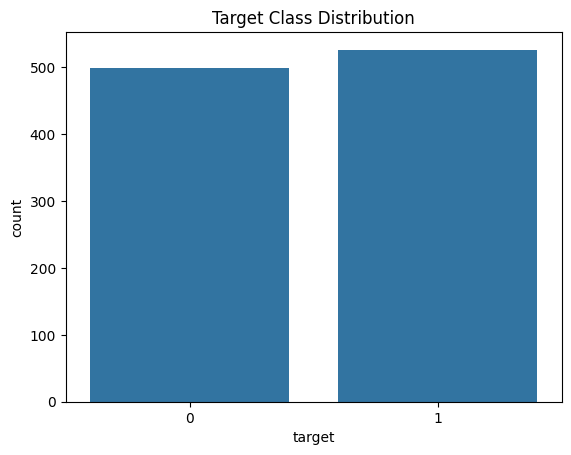

In [4]:
sns.countplot(x="target", data=df)
plt.title("Target Class Distribution")
plt.show()


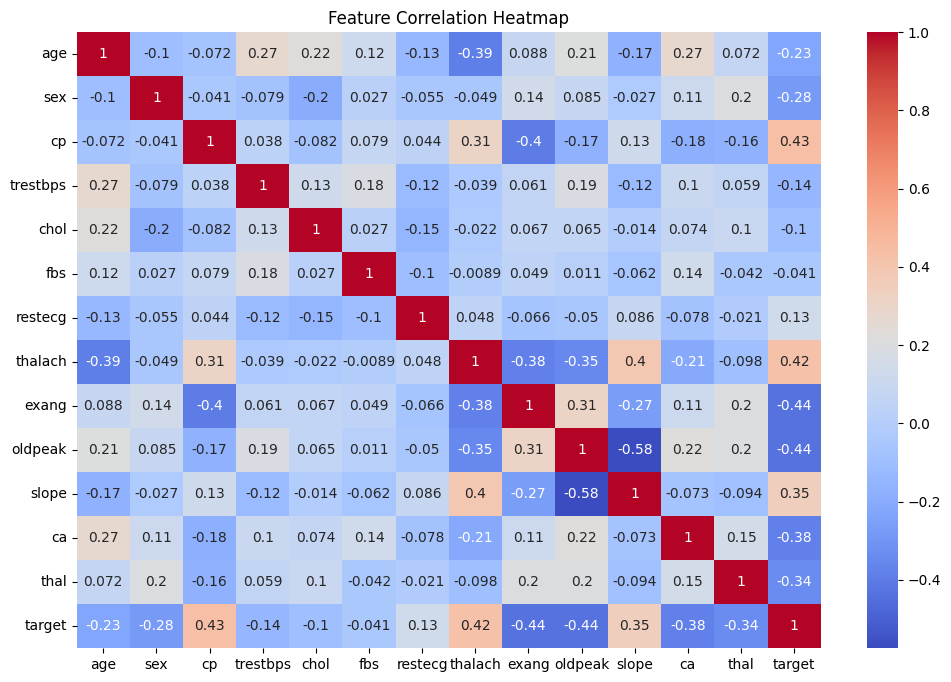

In [5]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [6]:
X = df.drop("target", axis=1)
y = df["target"]


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion="entropy",
    random_state=42
)


In [9]:
rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
y_pred = rf_model.predict(X_test)


In [12]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance


thalach     0.123280
oldpeak     0.120317
ca          0.118992
cp          0.117902
thal        0.099733
age         0.093313
chol        0.089040
trestbps    0.077363
exang       0.048268
slope       0.044468
sex         0.035270
restecg     0.021730
fbs         0.010324
dtype: float64

In [13]:
new_sample = pd.DataFrame({
    "age": [60],
    "sex": [1],
    "cp": [0],
    "trestbps": [130],
    "chol": [250],
    "fbs": [0],
    "restecg": [1],
    "thalach": [150],
    "exang": [0],
    "oldpeak": [1.5],
    "slope": [1],
    "ca": [1],
    "thal": [3]
})

prediction = rf_model.predict(new_sample)

result = "Heart Disease" if prediction[0] == 1 else "No Heart Disease"
result


'No Heart Disease'

## Feature Explanations for Heart Disease Prediction

1. **age**: Age of the patient in years (e.g., 60)

2. **sex**: Gender of the patient
   - 1 = Male
   - 0 = Female

3. **cp**: Chest pain type
   - 0 = Typical angina
   - 1 = Atypical angina
   - 2 = Non-anginal pain
   - 3 = Asymptomatic

4. **trestbps**: Resting blood pressure (mm Hg on admission to the hospital)

5. **chol**: Serum cholesterol level in mg/dl

6. **fbs**: Fasting blood sugar > 120 mg/dl
   - 1 = True
   - 0 = False

7. **restecg**: Resting electrocardiographic results
   - 0 = Normal
   - 1 = ST-T wave abnormality
   - 2 = Left ventricular hypertrophy

8. **thalach**: Maximum heart rate achieved during exercise

9. **exang**: Exercise induced angina
   - 1 = Yes
   - 0 = No

10. **oldpeak**: ST depression induced by exercise relative to rest

11. **slope**: Slope of the peak exercise ST segment
    - 0 = Upsloping
    - 1 = Flat
    - 2 = Downsloping

12. **ca**: Number of major vessels (0-3) colored by fluoroscopy

13. **thal**: Thalassemia (blood disorder)
    - 1 = Normal
    - 2 = Fixed defect
    - 3 = Reversible defect

In [14]:
new_sample = pd.DataFrame({
    "age": [60],
    "sex": [1],
    "cp": [0],
    "trestbps": [130],
    "chol": [250],
    "fbs": [0],
    "restecg": [1],
    "thalach": [150],
    "exang": [0],
    "oldpeak": [1.5],
    "slope": [1],
    "ca": [1],
    "thal": [3]
})


In [15]:
rf_model.predict(new_sample)
rf_model.predict_proba(new_sample)


array([[0.93, 0.07]])

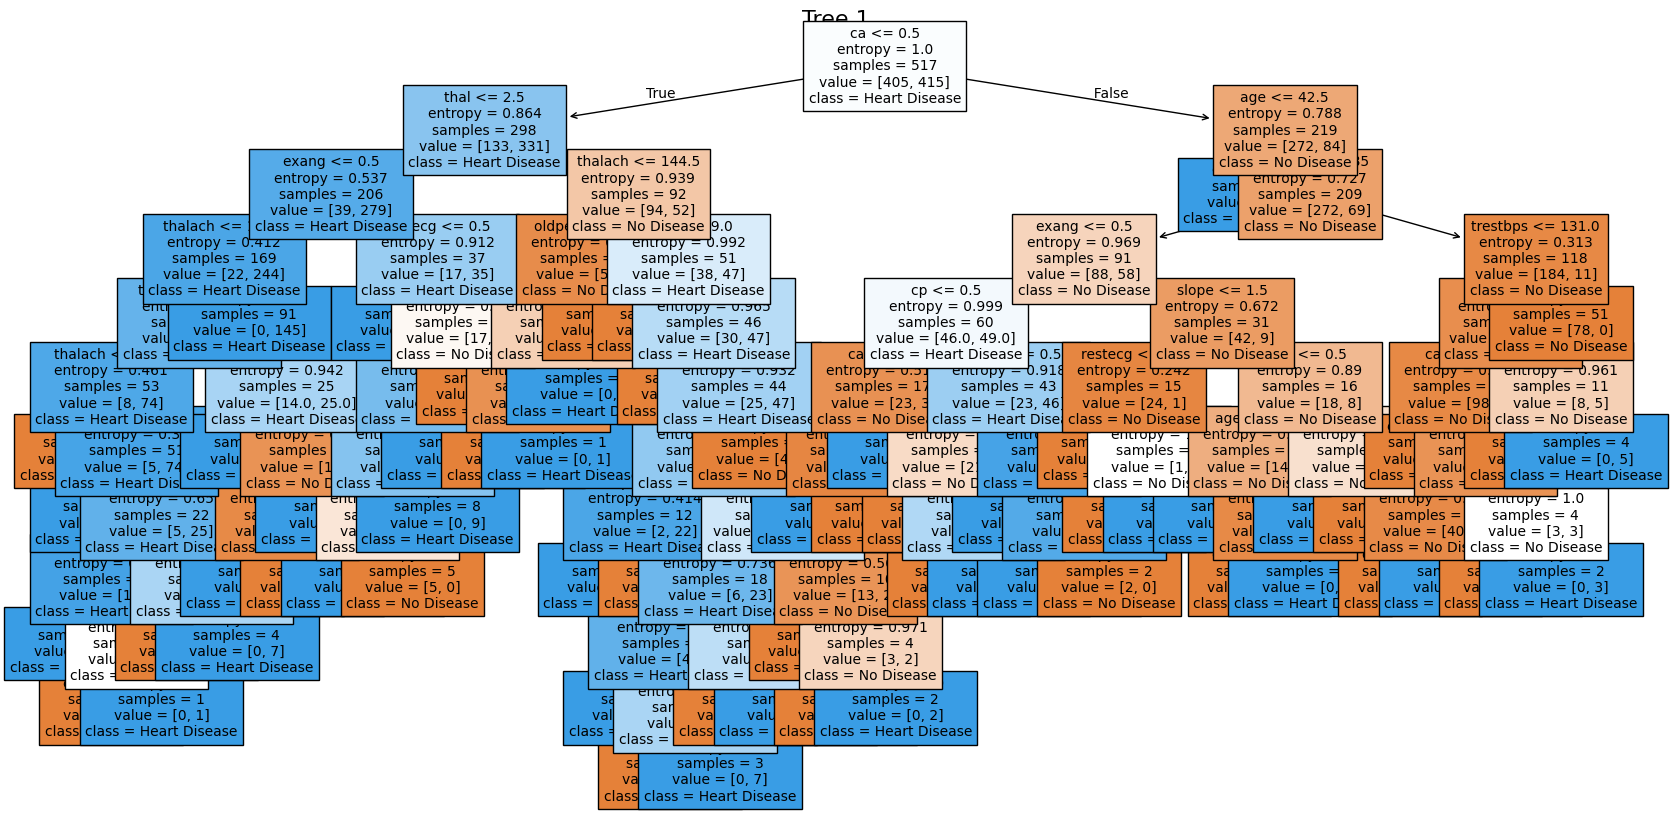

In [17]:
from sklearn.tree import plot_tree

# Visualize Tree 1
plt.figure(figsize=(20, 10))
plot_tree(
    rf_model.estimators_[0],
    feature_names=X.columns,
    class_names=['No Disease', 'Heart Disease'],
    filled=True,
    fontsize=10
)
plt.title('Tree 1', fontsize=16)
plt.show()

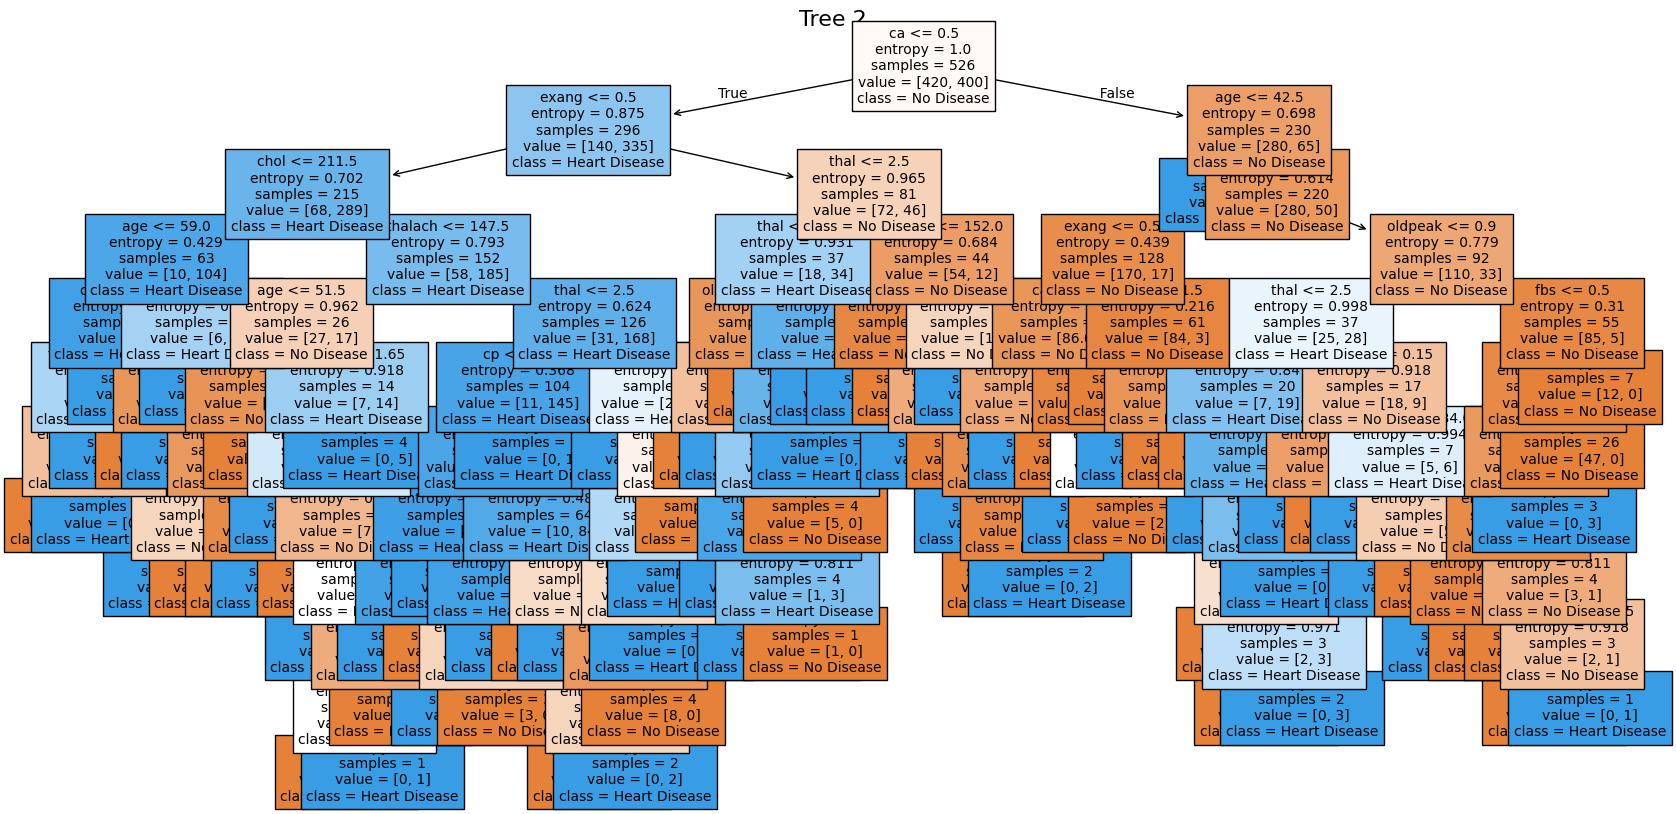

In [18]:
# Visualize Tree 2
plt.figure(figsize=(20, 10))
plot_tree(
    rf_model.estimators_[1],
    feature_names=X.columns,
    class_names=['No Disease', 'Heart Disease'],
    filled=True,
    fontsize=10
)
plt.title('Tree 2', fontsize=16)
plt.show()

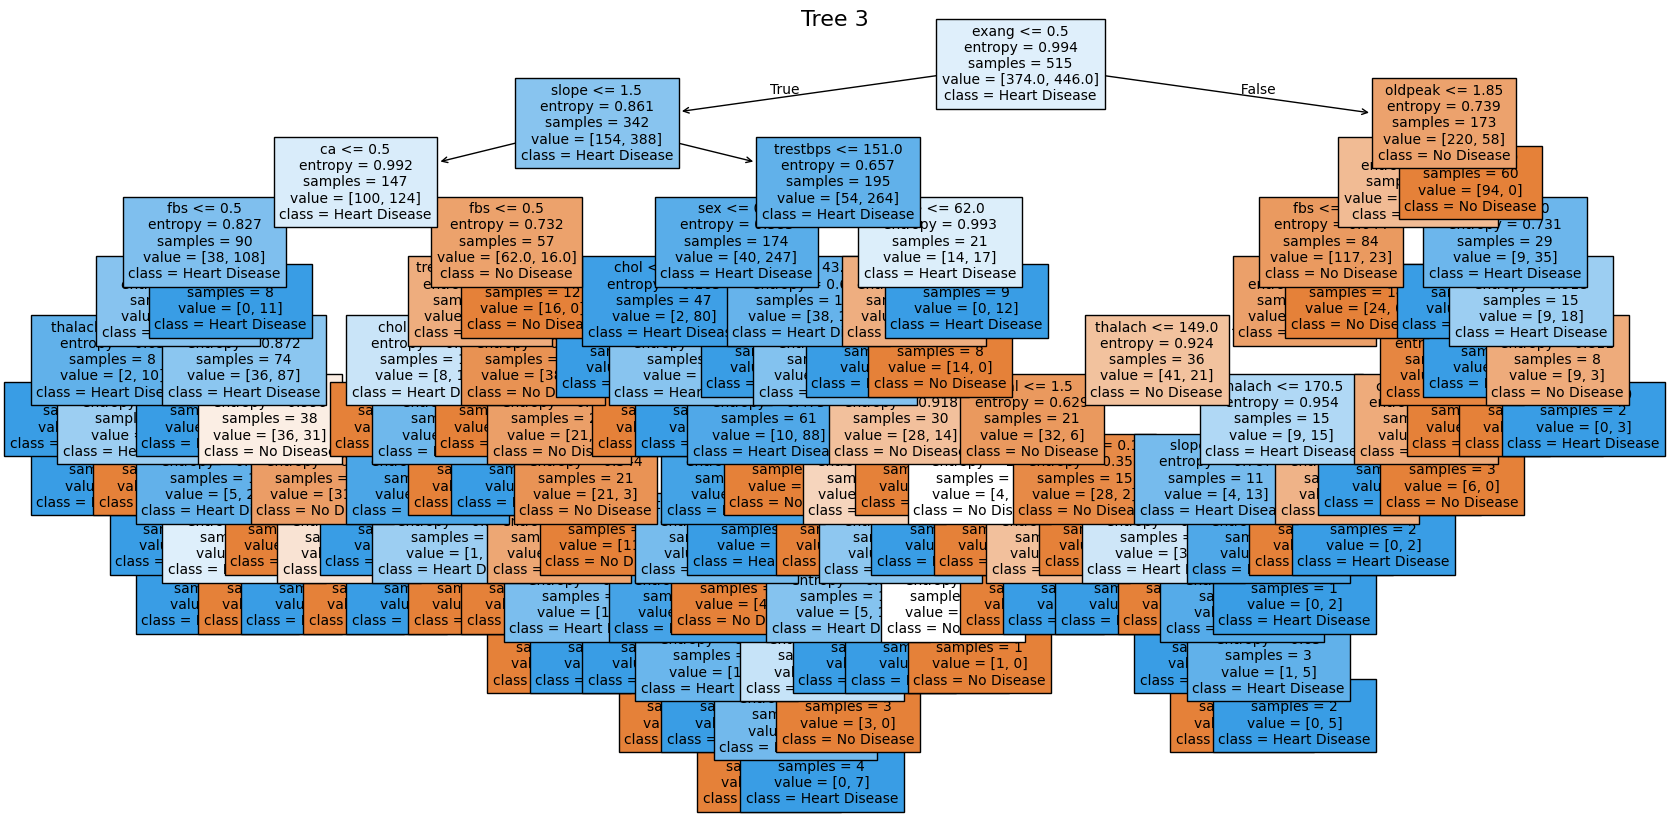

In [19]:
# Visualize Tree 3
plt.figure(figsize=(20, 10))
plot_tree(
    rf_model.estimators_[2],
    feature_names=X.columns,
    class_names=['No Disease', 'Heart Disease'],
    filled=True,
    fontsize=10
)
plt.title('Tree 3', fontsize=16)
plt.show()